# Graph Vizualization

In [0]:
import os
import sys
import glob
from os.path import abspath
# os.environ['SPARK_HOME'] = 'C:\spark-3.1.2-bin-hadoop3.2'
# os.environ['JAVA_HOME'] = 'C:\Program Files\Java\jdk1.8.0_201'
# os.environ['HADOOP_HOME'] = 'C:\spark-3.1.2-bin-hadoop3.2'
# spark_python = os.path.join(os.environ.get('SPARK_HOME',None),'python')
# py4j = glob.glob(os.path.join(spark_python,'lib','py4j-*.zip'))[0]
# graphf = glob.glob(os.path.join(spark_python,'graphframes.zip'))[0]
# sys.path[:0]=[spark_python,py4j]
# sys.path[:0]=[spark_python,graphf]
# os.environ['PYTHONPATH']=py4j+os.pathsep+graphf
# import findspark
# findspark.init()
# findspark.find()
# from pyspark.sql import SparkSession
# spark = SparkSession.builder.appName("Spark Examples").enableHiveSupport().getOrCreate()
from graphframes import *
import networkx as nx
import matplotlib.pyplot as plt

In [0]:
vertices = spark.createDataFrame([
    ("Alice", 45),
    ("Jacob", 43),
    ("Roy", 21),
    ("Ryan", 49),
    ("Emily", 24),
    ("Sheldon", 52)],
    ["id", "age"]
)

vertices.display()

id,age
Alice,45
Jacob,43
Roy,21
Ryan,49
Emily,24
Sheldon,52


In [0]:
edges = spark.createDataFrame([("Sheldon", "Alice", "Sister"),
                              ("Alice", "Jacob", "Husband"),
                              ("Emily", "Jacob", "Father"),
                              ("Ryan", "Alice", "Friend"),
                              ("Alice", "Emily", "Daughter"),
                              ("Alice", "Roy", "Son"),
                              ("Jacob", "Roy", "Son")],
                             ["src", "dst", "relation"])

edges.display()

src,dst,relation
Sheldon,Alice,Sister
Alice,Jacob,Husband
Emily,Jacob,Father
Ryan,Alice,Friend
Alice,Emily,Daughter
Alice,Roy,Son
Jacob,Roy,Son


In [0]:
family_tree = GraphFrame(vertices, edges)

## Graph Plot

### Undirected Graph
The function will plot the source and destination nodes and connect them by meand of undirected line

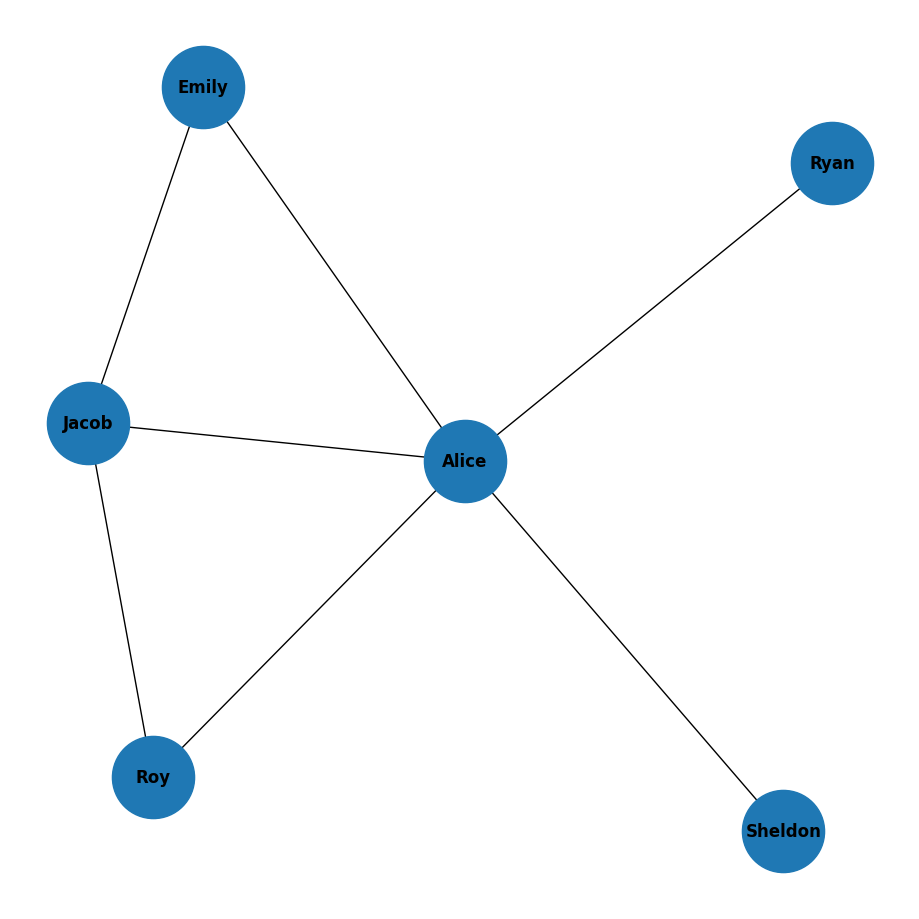

In [0]:
def plot_undirected_graph(edge_list):
    # edge list contains information about edges which have clear direction
    # however we will diregard the the direction in this function
    # the first thing is to plot the figure
    plt.figure(figsize=(9,9))
    # we instantiate a networkx graoh object.
    # nx. graoh represents an undirected graph.
    gplot=nx.Graph()
    for row in edge_list.select("src", "dst").take(1000):
        gplot.add_edge(row["src"], row["dst"])
    nx.draw(gplot, with_labels=True, font_weight="bold", node_size=3500)

plot_undirected_graph(family_tree.edges)

### Directed Graph
the function will plot the source and destination nodes and connect them by meand of undirected line

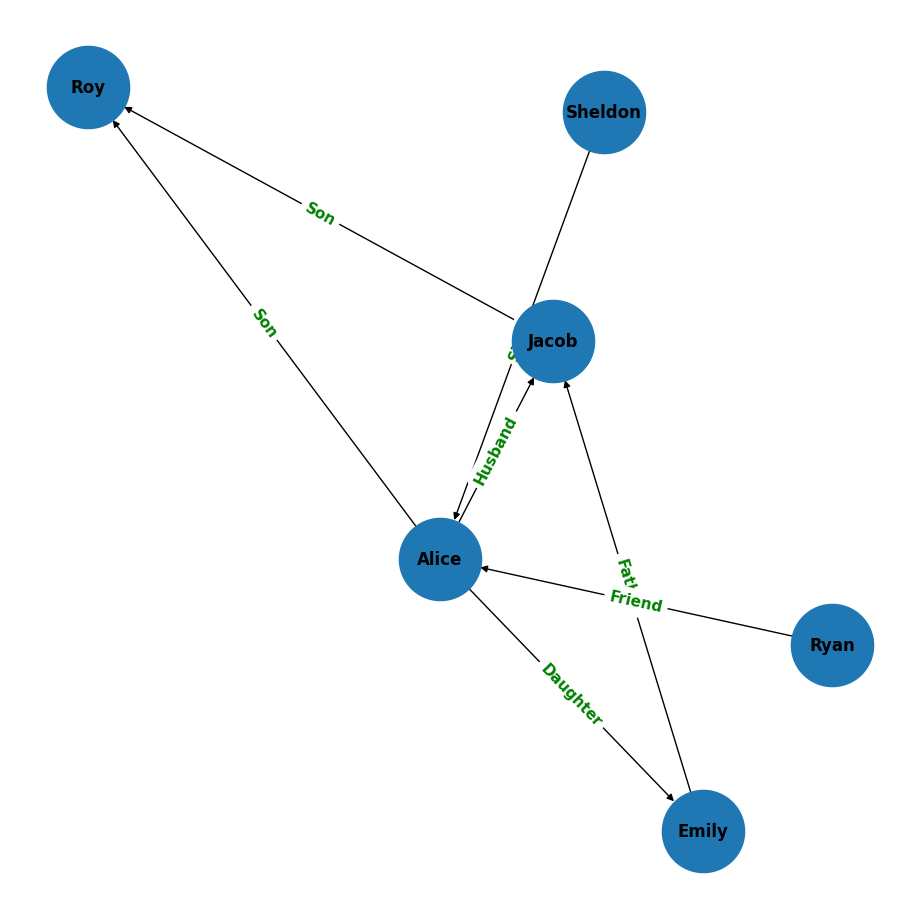

In [0]:
def plot_directed_graph(edge_list):
    plt.figure(figsize=(9,9))
    gplot=nx.DiGraph()
    edge_labels = {}
    for row in edge_list.select("src", "dst", "relation").take(1000):
        gplot.add_edge(row["src"], row["dst"])
        edge_labels[(row["src"], row["dst"])] = row["relation"]
    pos = nx.spring_layout(gplot)
    nx.draw(gplot, pos, with_labels=True, font_weight="bold", node_size=3500)
    nx.draw_networkx_edge_labels(gplot, pos, edge_labels=edge_labels, font_color="green", font_size=11, font_weight="bold")

    
plot_directed_graph(family_tree.edges)

# Degrees of Network

In [0]:
tree_degres = family_tree.degrees
tree_degres.display()

id,degree
Sheldon,1
Alice,5
Jacob,3
Emily,2
Ryan,1
Roy,2


In [0]:
degree_edges = edges.filter(("src = 'Alice' or dst = 'Alice'"))
degree_edges.display()

src,dst,relation
Sheldon,Alice,Sister
Alice,Jacob,Husband
Ryan,Alice,Friend
Alice,Emily,Daughter
Alice,Roy,Son


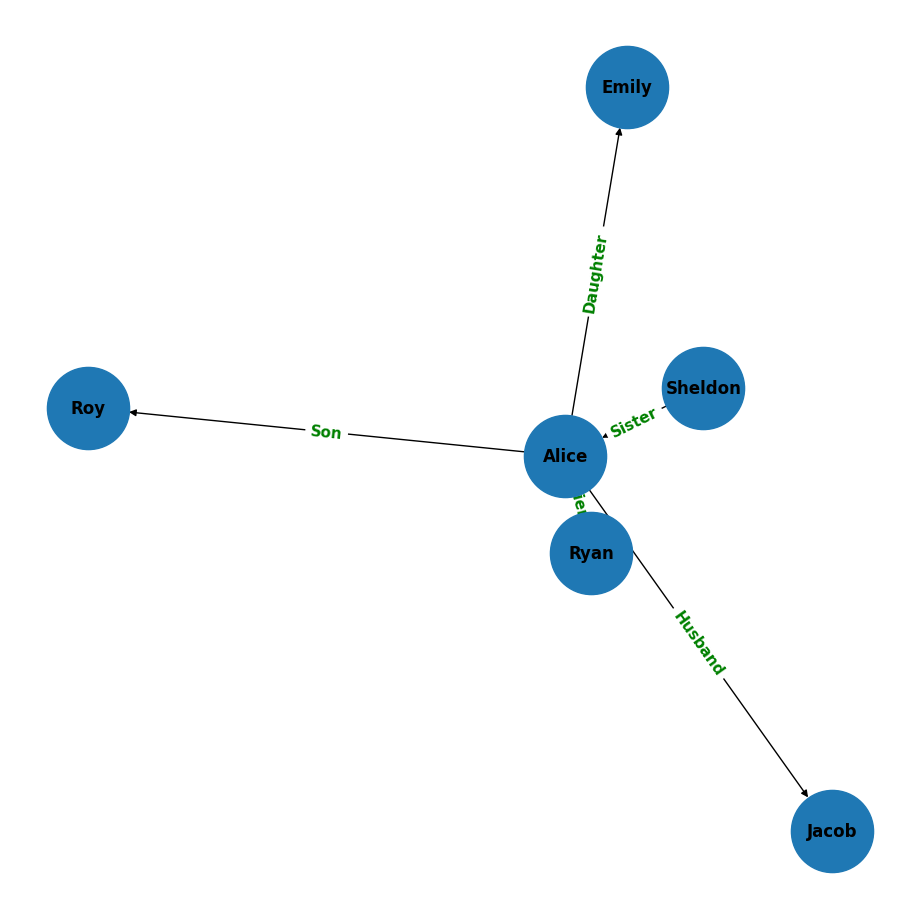

In [0]:
plot_directed_graph(degree_edges)

In [0]:
tree_inDegree = family_tree.inDegrees
tree_inDegree.display()

id,inDegree
Alice,2
Jacob,2
Emily,1
Roy,2


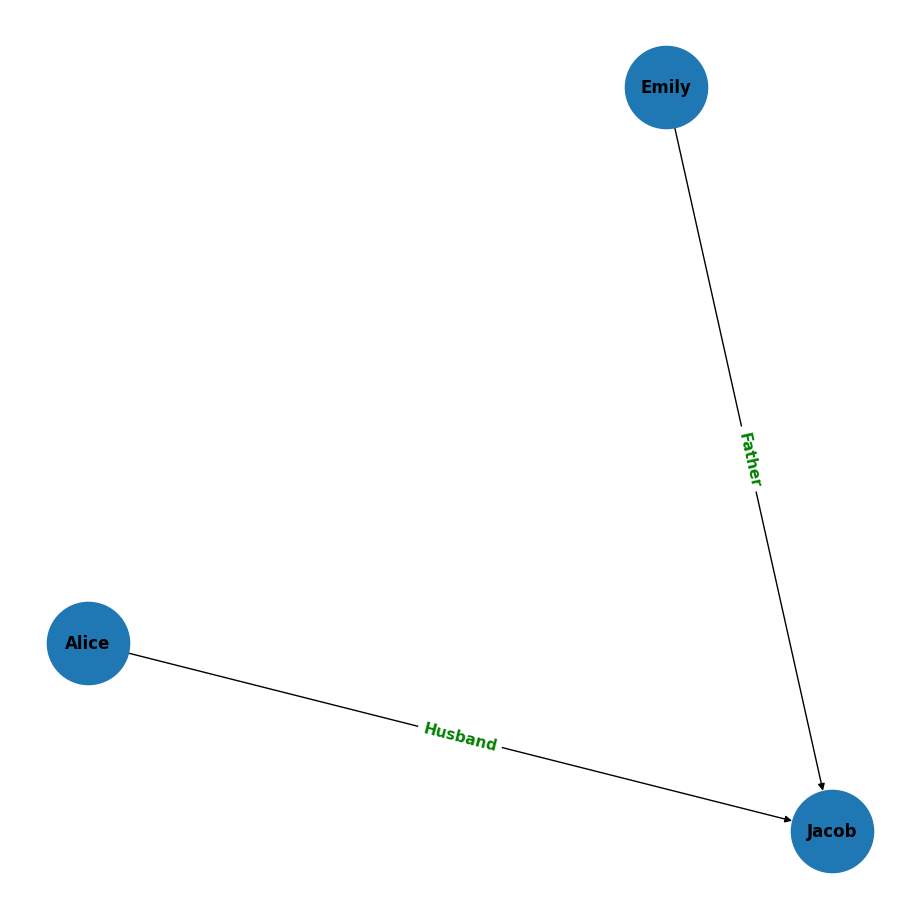

In [0]:
indegree_edges = edges.filter(("dst = 'Jacob'"))
plot_directed_graph(indegree_edges)

In [0]:
tree_outDegree = family_tree.outDegrees
tree_outDegree.display()

id,outDegree
Sheldon,1
Alice,3
Emily,1
Ryan,1
Jacob,1


# Finding MOTIFS in GraphFrame

Graph motifs are small connected subgraphs with a well-defined structure. These functions search a graph for various motifs. A connected graph that has many occurrences in a network is called a motif of the network.

Simply put, Network motifs are recurring, significant patterns of interconnections in the network. Here, pattern means it is a small induced subgraph.

In [0]:
import os
import sys
import glob
from os.path import abspath
# os.environ['SPARK_HOME'] = 'C:\spark-3.1.2-bin-hadoop3.2'
# os.environ['JAVA_HOME'] = 'C:\Program Files\Java\jdk1.8.0_201'
# os.environ['HADOOP_HOME'] = 'C:\spark-3.1.2-bin-hadoop3.2'
# spark_python = os.path.join(os.environ.get('SPARK_HOME',None),'python')
# py4j = glob.glob(os.path.join(spark_python,'lib','py4j-*.zip'))[0]
# graphf = glob.glob(os.path.join(spark_python,'graphframes.zip'))[0]
# sys.path[:0]=[spark_python,py4j]
# sys.path[:0]=[spark_python,graphf]
# os.environ['PYTHONPATH']=py4j+os.pathsep+graphf
# import findspark
# findspark.init()
# findspark.find()
# from pyspark.sql import SparkSession
# spark = SparkSession.builder.appName("Spark Examples").enableHiveSupport().getOrCreate()
from graphframes import *
import networkx as nx
import matplotlib.pyplot as plt

In [0]:
vertices = spark.createDataFrame([("James", "Software Engineer"),
                                 ("Mary", "Software Engineer"),
                                 ("Roy", "Product Developer"),
                                 ("Ryan", "HR"),
                                 ("John", "Security"),
                                 ("Robert", "Testing Engineer")], ["id", "Designation"])
vertices.display()

id,Designation
James,Software Engineer
Mary,Software Engineer
Roy,Product Developer
Ryan,HR
John,Security
Robert,Testing Engineer


In [0]:
edges = spark.createDataFrame([("James", "Mary", "colleagues"),
                              ("Mary", "James", "colleagues"),
                              ("Roy", "James", "friends"),
                              ("James", "Roy", "friends"),
                              ("Mary", "Roy", "neighbours"),
                              ("Roy", "Mary", "neighbours"),
                              ("Roy", "Ryan", "friends"),
                              ("Ryan", "Roy", "friends"),
                              ("James", "Ryan", "friends"),
                              ("Ryan", "James", "friends"),
                              ("John", "Roy", "friends"),
                              ("Roy", "John", "friends"),
                              ("Ryan", "John", "reportsto"),
                              ("Robert", "John", "reportsto")],
                             ["src", "dst", "type"])
edges.display()

src,dst,type
James,Mary,colleagues
Mary,James,colleagues
Roy,James,friends
James,Roy,friends
Mary,Roy,neighbours
Roy,Mary,neighbours
Roy,Ryan,friends
Ryan,Roy,friends
James,Ryan,friends
Ryan,James,friends


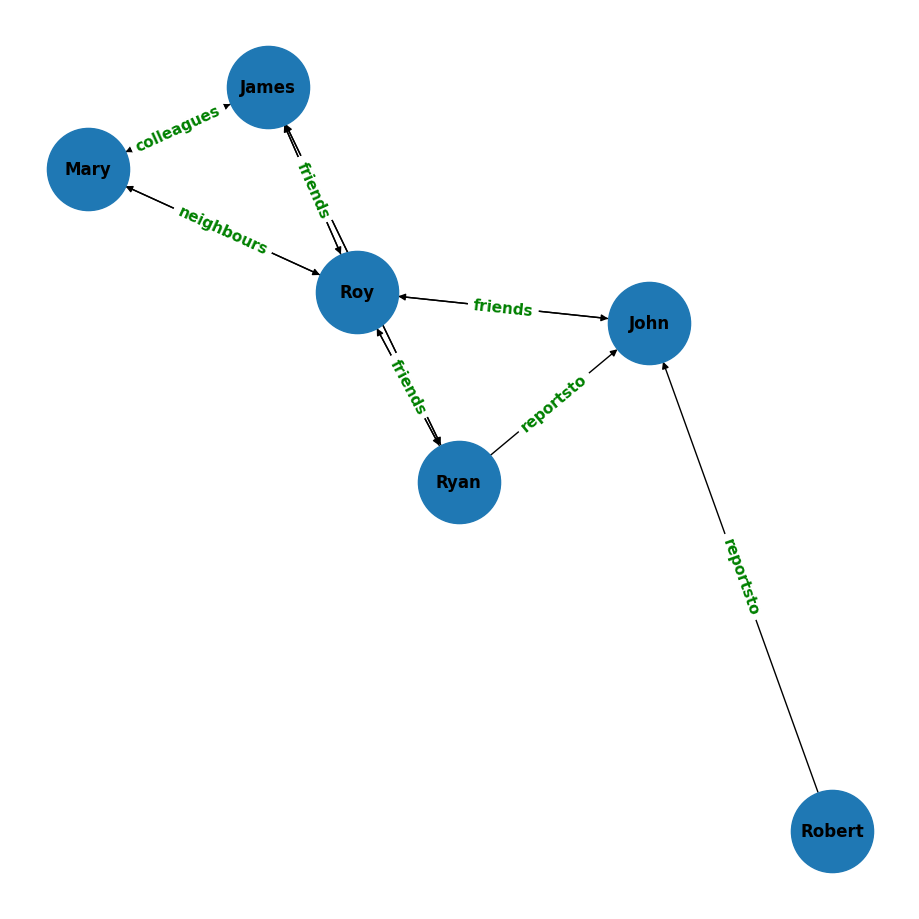

In [0]:
g = GraphFrame(vertices, edges)
# the function will plot the source and destination nodes and connect them by meand of undirected line
def plot_directed_graph(edge_list):
    plt.figure(figsize=(9,9))
    gplot=nx.DiGraph()
    edge_labels = {}
    for row in edge_list.select("src", "dst", "type").take(1000):
        gplot.add_edge(row["src"], row["dst"])
        edge_labels[(row["src"], row["dst"])] = row["type"]
    pos = nx.spring_layout(gplot)
    nx.draw(gplot, pos, with_labels=True, font_weight="bold", node_size=3500)
    nx.draw_networkx_edge_labels(gplot, pos, edge_labels=edge_labels, font_color="green", font_size=11, font_weight="bold")

plot_directed_graph(g.edges)


# def plot_directed_graph(edge_list):
#     plt.figure(figsize=(9,9))
#     gplot=nx.DiGraph()
#     edge_labels = {}
#     for row in edge_list.select("src", "dst", "relation").take(1000):
#         gplot.add_edge(row["src"], row["dst"])
#         edge_labels[(row["src"], row["dst"])] = row["relation"]
#     pos = nx.spring_layout(gplot)
#     nx.draw(gplot, pos, with_labels=True, font_weight="bold", node_size=3500)
#     nx.draw_networkx_edge_labels(gplot, pos, edge_labels=edge_labels, font_color="green", font_size=11, font_weight="bold")

In [0]:
simple_motifs = g.find("(start_vertex)-[edge]->(end_vertex)")
simple_motifs.display(truncate=False)
simple_motifs.count()

start_vertex,edge,end_vertex
"List(Ryan, HR)","List(Ryan, James, friends)","List(James, Software Engineer)"
"List(Roy, Product Developer)","List(Roy, James, friends)","List(James, Software Engineer)"
"List(Mary, Software Engineer)","List(Mary, James, colleagues)","List(James, Software Engineer)"
"List(Roy, Product Developer)","List(Roy, Mary, neighbours)","List(Mary, Software Engineer)"
"List(James, Software Engineer)","List(James, Mary, colleagues)","List(Mary, Software Engineer)"
"List(Ryan, HR)","List(Ryan, Roy, friends)","List(Roy, Product Developer)"
"List(Mary, Software Engineer)","List(Mary, Roy, neighbours)","List(Roy, Product Developer)"
"List(John, Security)","List(John, Roy, friends)","List(Roy, Product Developer)"
"List(James, Software Engineer)","List(James, Roy, friends)","List(Roy, Product Developer)"
"List(Roy, Product Developer)","List(Roy, Ryan, friends)","List(Ryan, HR)"


14

In [0]:
simple_motifs = g.find("(start_vertex)-[edge]->(end_vertex)")
simple_motifs.show(truncate=False)
simple_motifs.count()

+--------------------------+-------------------------+--------------------------+
|start_vertex              |edge                     |end_vertex                |
+--------------------------+-------------------------+--------------------------+
|{Ryan, HR}                |{Ryan, James, friends}   |{James, Software Engineer}|
|{Roy, Product Developer}  |{Roy, James, friends}    |{James, Software Engineer}|
|{Mary, Software Engineer} |{Mary, James, colleagues}|{James, Software Engineer}|
|{Roy, Product Developer}  |{Roy, Mary, neighbours}  |{Mary, Software Engineer} |
|{James, Software Engineer}|{James, Mary, colleagues}|{Mary, Software Engineer} |
|{Ryan, HR}                |{Ryan, Roy, friends}     |{Roy, Product Developer}  |
|{Mary, Software Engineer} |{Mary, Roy, neighbours}  |{Roy, Product Developer}  |
|{John, Security}          |{John, Roy, friends}     |{Roy, Product Developer}  |
|{James, Software Engineer}|{James, Roy, friends}    |{Roy, Product Developer}  |
|{Roy, Product D

14

In [0]:
filtered_motifs = g.find("(start_vertex)-[edge]->(end_vertex)").filter("edge.type='friends'")
filtered_motifs.display(truncate=False)
filtered_motifs.count()

start_vertex,edge,end_vertex
"List(Ryan, HR)","List(Ryan, James, friends)","List(James, Software Engineer)"
"List(Roy, Product Developer)","List(Roy, James, friends)","List(James, Software Engineer)"
"List(Ryan, HR)","List(Ryan, Roy, friends)","List(Roy, Product Developer)"
"List(John, Security)","List(John, Roy, friends)","List(Roy, Product Developer)"
"List(James, Software Engineer)","List(James, Roy, friends)","List(Roy, Product Developer)"
"List(Roy, Product Developer)","List(Roy, Ryan, friends)","List(Ryan, HR)"
"List(James, Software Engineer)","List(James, Ryan, friends)","List(Ryan, HR)"
"List(Roy, Product Developer)","List(Roy, John, friends)","List(John, Security)"


8

In [0]:
filtered_motifs = g.find("(start_vertex)-[edge]->(end_vertex)")\
                    .filter("start_vertex.id='Roy' AND edge.type='friends'")
filtered_motifs.display(truncate=False)
filtered_motifs.count()

start_vertex,edge,end_vertex
"List(Roy, Product Developer)","List(Roy, James, friends)","List(James, Software Engineer)"
"List(Roy, Product Developer)","List(Roy, Ryan, friends)","List(Ryan, HR)"
"List(Roy, Product Developer)","List(Roy, John, friends)","List(John, Security)"


3

In [0]:
filtered_motifs.select("start_vertex.id", "edge.type", "end_vertex.id").display(truncate=False)

id,type,id
Roy,friends,James
Roy,friends,Ryan
Roy,friends,John


# Finding Path

In [0]:
import os
import sys
import glob
from os.path import abspath
# os.environ['SPARK_HOME'] = 'C:\spark-3.1.2-bin-hadoop3.2'
# os.environ['JAVA_HOME'] = 'C:\Program Files\Java\jdk1.8.0_201'
# os.environ['HADOOP_HOME'] = 'C:\spark-3.1.2-bin-hadoop3.2'
# spark_python = os.path.join(os.environ.get('SPARK_HOME',None),'python')
# py4j = glob.glob(os.path.join(spark_python,'lib','py4j-*.zip'))[0]
# graphf = glob.glob(os.path.join(spark_python,'graphframes.zip'))[0]
# sys.path[:0]=[spark_python,py4j]
# sys.path[:0]=[spark_python,graphf]
# os.environ['PYTHONPATH']=py4j+os.pathsep+graphf
# import findspark
# findspark.init()
# findspark.find()
# from pyspark.sql import SparkSession
# spark = SparkSession.builder.appName("Spark Examples").enableHiveSupport().getOrCreate()

from graphframes import *
import networkx as nx
import matplotlib.pyplot as plt

In [0]:
import pandas as pd

In [0]:
# transport_nodes = spark.read.format("csv").option("inferSchema", "true").option("header", "true").load("transport-nodes.csv")
transport_nodes_ = pd.read_csv("transport-nodes.csv")
transport_nodes = spark.createDataFrame(transport_nodes_)
transport_nodes.display()

id,latitude,longitude,population
Amsterdam,52.379189,4.899431,821752
Utrecht,52.092876,5.10448,334176
Den Haag,52.078663,4.288788,514861
Immingham,53.61239,-0.22219,9642
Doncaster,53.52285,-1.13116,302400
Hoek van Holland,51.9775,4.13333,9382
Felixstowe,51.96375,1.3511,23689
Ipswich,52.05917,1.15545,133384
Colchester,51.88921,0.90421,104390
London,51.509865,-0.118092,8787892


In [0]:
# transport_relationships = spark.read.format("csv").option("inferSchema", "true").option("header", "true").load("transport-relationships.csv")
transport_relationships_ = pd.read_csv("transport-relationships.csv")
transport_relationships = spark.createDataFrame(transport_relationships_)
transport_relationships.display()

src,dst,relationship,cost
Amsterdam,Utrecht,BUS,46
Amsterdam,Den Haag,BUS,59
Den Haag,Rotterdam,BUS,26
Amsterdam,Immingham,TAXI,369
Immingham,Doncaster,BUS,74
Doncaster,London,TAXI,277
Hoek van Holland,Den Haag,BUS,27
Felixstowe,Hoek van Holland,TAXI,207
Ipswich,Felixstowe,BUS,22
Colchester,Ipswich,BUS,32


In [0]:
# the function will plot the source and destination nodes and connect them by meand of undirected line
def plot_directed_graph(edge_list):
    plt.figure(figsize=(9,9))
    gplot=nx.DiGraph()
    edge_labels = {}
    for row in edge_list.select("src", "dst", "cost").take(1000):
        gplot.add_edge(row["src"], row["dst"])
        edge_labels[(row["src"], row["dst"])] = row["cost"]
    pos = nx.spring_layout(gplot)
    nx.draw(gplot, pos, with_labels=True, font_weight="bold", node_size=3500)
    nx.draw_networkx_edge_labels(gplot, pos, edge_labels=edge_labels, font_color="green", font_size=11, font_weight="bold")

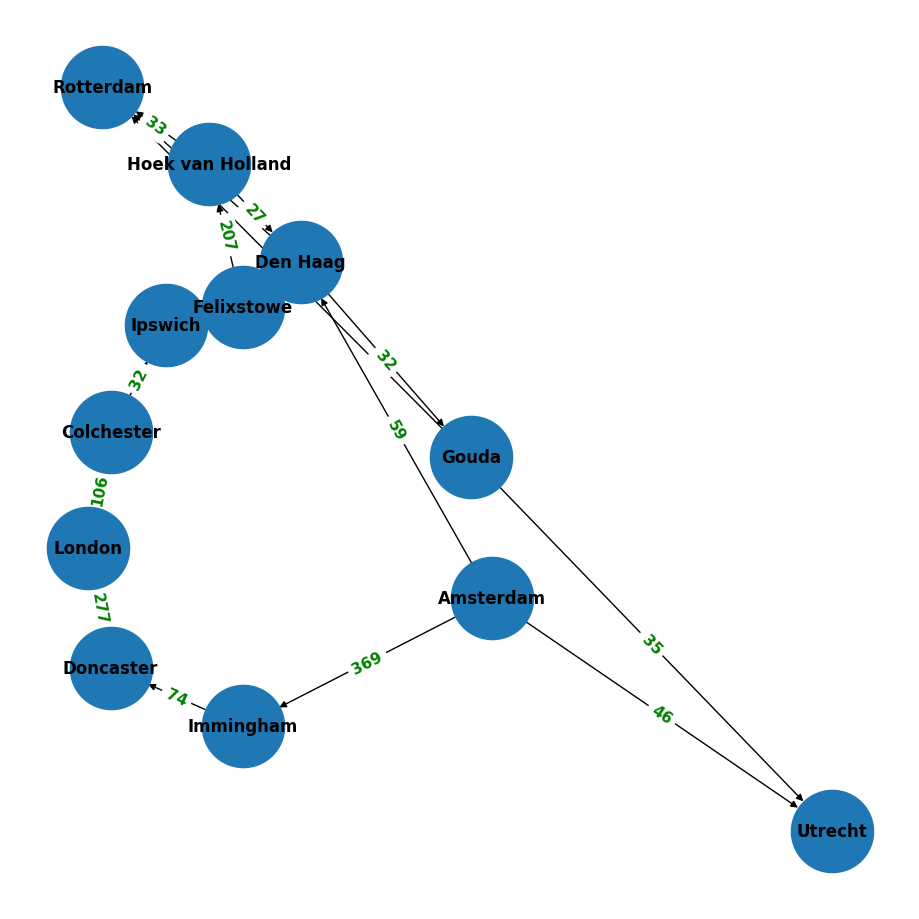

In [0]:
route = GraphFrame(transport_nodes, transport_relationships)
plot_directed_graph(route.edges)

## Breadth-First Search (BFS)

In [0]:
# finding the shortest path between Gouda and Utrecht using BFS
shortest_path = route.bfs(fromExpr="id='Gouda'", toExpr="id='Utrecht'", maxPathLength=3)
shortest_path.display(truncate=False)
shortest_path.count()

from,e0,to
"List(Gouda, 52.01667, 4.70833, 70939)","List(Gouda, Utrecht, BUS, 35)","List(Utrecht, 52.092876, 5.10448, 334176)"


1

In [0]:
# finding the shortest path between Gouda and Felixtowe using BFS
shortest_path = route.bfs(fromExpr="id='Gouda'", toExpr="id='Felixtowe'", maxPathLength=3)
shortest_path.display(truncate=False)
shortest_path.count()

id,latitude,longitude,population


0

In [0]:
# finding the shortest path between Amsterdam and Felixtowe using BFS
# shortest_path = route.bfs(fromExpr="id='Amsterdam'", toExpr="id='Felixtowe'", maxPathLength=3)
filtered_paths = route.bfs("id = 'Amsterdam'", "id = 'Felixstowe'")
filtered_paths.display(truncate=False)
filtered_paths.count()

from,e0,v1,e1,v2,e2,v3,e3,v4,e4,v5,e5,to
"List(Amsterdam, 52.379189, 4.899431, 821752)","List(Amsterdam, Immingham, TAXI, 369)","List(Immingham, 53.61239, -0.22219, 9642)","List(Immingham, Doncaster, BUS, 74)","List(Doncaster, 53.52285, -1.13116, 302400)","List(Doncaster, London, TAXI, 277)","List(London, 51.509865, -0.118092, 8787892)","List(London, Colchester, TAXI, 106)","List(Colchester, 51.88921, 0.90421, 104390)","List(Colchester, Ipswich, BUS, 32)","List(Ipswich, 52.05917, 1.15545, 133384)","List(Ipswich, Felixstowe, BUS, 22)","List(Felixstowe, 51.96375, 1.3511, 23689)"


1

In [0]:
filtered_paths = route.bfs("id = 'Amsterdam'", "population < 500000")
filtered_paths.display(truncate=False)
filtered_paths.count()

from,e0,to
"List(Amsterdam, 52.379189, 4.899431, 821752)","List(Amsterdam, Utrecht, BUS, 46)","List(Utrecht, 52.092876, 5.10448, 334176)"
"List(Amsterdam, 52.379189, 4.899431, 821752)","List(Amsterdam, Immingham, TAXI, 369)","List(Immingham, 53.61239, -0.22219, 9642)"


2

In [0]:
filtered_paths = route.bfs("id = 'Amsterdam'", "id = 'London'", maxPathLength=5)
filtered_paths.display(truncate=False)
filtered_paths.count()

from,e0,v1,e1,v2,e2,to
"List(Amsterdam, 52.379189, 4.899431, 821752)","List(Amsterdam, Immingham, TAXI, 369)","List(Immingham, 53.61239, -0.22219, 9642)","List(Immingham, Doncaster, BUS, 74)","List(Doncaster, 53.52285, -1.13116, 302400)","List(Doncaster, London, TAXI, 277)","List(London, 51.509865, -0.118092, 8787892)"


1

## Shortest Paths Function

In [0]:
# finding the shortest path between Gouda and Utrecht
shortest_path = route.shortestPaths(landmarks=["Gouda", "Utrecht"])
shortest_path.display(truncate=False)
shortest_path.count()

id,latitude,longitude,population,distances
Rotterdam,51.9225,4.47917,623652,Map()
Amsterdam,52.379189,4.899431,821752,"Map(Utrecht -> 1, Gouda -> 2)"
Utrecht,52.092876,5.10448,334176,Map(Utrecht -> 0)
Den Haag,52.078663,4.288788,514861,"Map(Utrecht -> 2, Gouda -> 1)"
Felixstowe,51.96375,1.3511,23689,"Map(Utrecht -> 4, Gouda -> 3)"
Hoek van Holland,51.9775,4.13333,9382,"Map(Utrecht -> 3, Gouda -> 2)"
London,51.509865,-0.118092,8787892,"Map(Utrecht -> 7, Gouda -> 6)"
Immingham,53.61239,-0.22219,9642,"Map(Utrecht -> 9, Gouda -> 8)"
Gouda,52.01667,4.70833,70939,"Map(Utrecht -> 1, Gouda -> 0)"
Colchester,51.88921,0.90421,104390,"Map(Utrecht -> 6, Gouda -> 5)"


12